# 🚀 Lab 35: Statistical Significance in A/B Testing

## 📘 Lab Overview
In this lab, you will learn how to evaluate whether the result of an A/B test is statistically meaningful. You will generate realistic A/B testing data, compare two website designs, run a two-sample t-test, calculate p-values, compute confidence intervals, interpret the business meaning of the results, and create visualizations that explain the outcome clearly.

### 🎯 Objectives
* Understand the fundamentals of A/B testing and statistical significance.
* Implement two-sample t-tests using the `scipy.stats` library.
* Calculate and interpret p-values for hypothesis testing.
* Compute confidence intervals for statistical comparisons.
* Determine whether design B outperforms design A with statistical significance.

### 🧰 Prerequisites
* Basic understanding of Python (pandas, numpy).
* Basic statistics concepts (mean, standard deviation, hypothesis testing).

## ⚙️ Colab Environment Setup
First, we need to ensure all required libraries are installed and imported. We will also create directories to store our generated reports and visualizations.

**ELI10 Explanation:** Think of this as setting up your workbench. We are getting our tools (libraries) ready and making folders to keep our finished work organized.

In [1]:
# Install necessary libraries if they aren't already available
!pip install numpy pandas scipy matplotlib seaborn

import os
import warnings
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, norm

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

# Set random seed for reproducibility (ensures you get the same 'random' data every time)
np.random.seed(42)

# Create folders for outputs to keep the workspace clean
os.makedirs("reports", exist_ok=True)
os.makedirs("visualizations", exist_ok=True)

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"SciPy version: {scipy.__version__}")

Libraries imported successfully!
NumPy version: 2.0.2
Pandas version: 2.2.2
SciPy version: 1.16.3


## 📥 Loading or Creating the Dataset
We will simulate a realistic A/B testing scenario. Imagine we have a current website (**Design A**) and a new layout (**Design B**). We want to see if the new layout increases the number of users who click 'Buy' (the conversion rate).

**ELI10 Explanation:** We are creating a fake list of 2,000 visitors. Half saw the old site, and half saw the new site. We mark '1' if they bought something and '0' if they didn't.

In [2]:
# Scenario: Testing two website designs for conversion rates

# Design A (Control Group) - Current website design
n_a = 1000
conversion_rate_a = 0.12 # 12% baseline conversion
group_a = np.random.binomial(1, conversion_rate_a, n_a)

# Design B (Treatment Group) - New website design
n_b = 1000
conversion_rate_b = 0.15 # 15% target conversion
group_b = np.random.binomial(1, conversion_rate_b, n_b)

# Create DataFrames for organized data handling
df_a = pd.DataFrame({
    'group': 'A',
    'converted': group_a,
    'user_id': range(1, n_a + 1)
})

df_b = pd.DataFrame({
    'group': 'B',
    'converted': group_b,
    'user_id': range(n_a + 1, n_a + n_b + 1)
})

# Combine datasets into one master DataFrame
ab_data = pd.concat([df_a, df_b], ignore_index=True)

# Save raw dataset to CSV for record keeping
ab_data.to_csv("ab_test_raw_data.csv", index=False)

print("Sample A/B testing data generated and saved to 'ab_test_raw_data.csv':")
print(f"Group A size: {len(df_a)}")
print(f"Group B size: {len(df_b)}")
print("\nFirst 5 rows of the combined dataset:")
display(ab_data.head())

Sample A/B testing data generated and saved to 'ab_test_raw_data.csv':
Group A size: 1000
Group B size: 1000

First 5 rows of the combined dataset:


,group,converted,user_id
0,A,0,1
1,A,1,2
2,A,0,3
3,A,0,4
4,A,0,5


## 🔍 Data Exploration
Before jumping into math, we look at the data. We calculate the actual conversion rates we observed in our sample.

**ELI10 Explanation:** We are counting the 'wins' for each group to see which design looks better at first glance.

In [3]:
# Calculate basic statistics for both groups
summary_stats = ab_data.groupby('group')['converted'].agg([
    'count', 'sum', 'mean', 'std'
]).round(4)

summary_stats.columns = ['Sample_Size', 'Conversions', 'Conversion_Rate', 'Std_Dev']

print("A/B Testing Summary Statistics:")
display(summary_stats)

# Calculate the observed difference
rate_a = summary_stats.loc['A', 'Conversion_Rate']
rate_b = summary_stats.loc['B', 'Conversion_Rate']
difference = rate_b - rate_a

print(f"\nConversion Rate Difference (B - A): {difference:.4f}")
print(f"Percentage Point Improvement: {difference * 100:.2f}%")

A/B Testing Summary Statistics:


,Sample_Size,Conversions,Conversion_Rate,Std_Dev
group,,,,
A,1000,124,0.124,0.3297
B,1000,152,0.152,0.3592



Conversion Rate Difference (B - A): 0.0280
Percentage Point Improvement: 2.80%


## 📊 Detailed Data Exploration
Before proceeding to significance tests, it's vital to check the health of our data. We verify row counts, data types, and check for any missing values to ensure our analysis isn't skewed by corrupted data.

**ELI10 Explanation:** This is like checking our list to make sure no names were skipped and that we didn't write down any gibberish instead of numbers.

In [17]:
# Data Health Check: Inspecting the structure and quality of the dataset
print("=== DATASET OVERVIEW ===")
print(f"Total rows: {len(ab_data)}")
print(f"Columns: {list(ab_data.columns)}")
print(f"Data types:\n{ab_data.dtypes}")

print("\n=== BASIC SUMMARY ===")
display(ab_data.describe())

print("\n=== GROUP COUNTS ===")
print(ab_data['group'].value_counts())

print("\n=== MISSING VALUES CHECK ===")
print(ab_data.isnull().sum())

=== DATASET OVERVIEW ===
Total rows: 2000
Columns: ['group', 'converted', 'user_id']
Data types:
group        object
converted     int64
user_id       int64
dtype: object

=== BASIC SUMMARY ===


,converted,user_id
count,2000.000000,2000.000000
mean,0.138000,1000.500000
std,0.344986,577.494589
min,0.000000,1.000000
25%,0.000000,500.750000
50%,0.000000,1000.500000
75%,0.000000,1500.250000
max,1.000000,2000.000000



=== GROUP COUNTS ===
group
A    1000
B    1000
Name: count, dtype: int64

=== MISSING VALUES CHECK ===
group        0
converted    0
user_id      0
dtype: int64


## 📊 Detailed Data Exploration
Before proceeding to significance tests, it's vital to check the health of our data. We verify row counts, data types, and check for any missing values to ensure our analysis isn't skewed by corrupted data.

In [13]:
print("=== DATASET OVERVIEW ===")
print(f"Total rows: {len(ab_data)}")
print(f"Columns: {list(ab_data.columns)}")
print(f"Data types:\n{ab_data.dtypes}")

print("\n=== BASIC SUMMARY ===")
display(ab_data.describe())

print("\n=== GROUP COUNTS ===")
print(ab_data['group'].value_counts())

print("\n=== MISSING VALUES CHECK ===")
print(ab_data.isnull().sum())

=== DATASET OVERVIEW ===
Total rows: 2000
Columns: ['group', 'converted', 'user_id']
Data types:
group        object
converted     int64
user_id       int64
dtype: object

=== BASIC SUMMARY ===


,converted,user_id
count,2000.000000,2000.000000
mean,0.138000,1000.500000
std,0.344986,577.494589
min,0.000000,1.000000
25%,0.000000,500.750000
50%,0.000000,1000.500000
75%,0.000000,1500.250000
max,1.000000,2000.000000



=== GROUP COUNTS ===
group
A    1000
B    1000
Name: count, dtype: int64

=== MISSING VALUES CHECK ===
group        0
converted    0
user_id      0
dtype: int64


### 📊 Visualizing Conversion Rates
Graphs make it easier to see the difference between Group A and Group B.

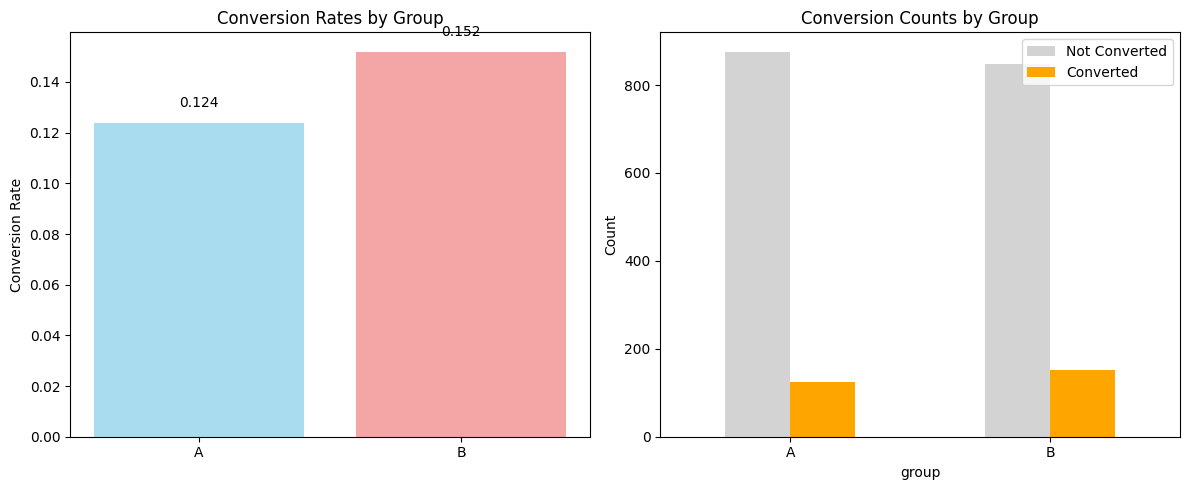

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot of conversion rates
conversion_rates = ab_data.groupby('group')['converted'].mean()
axes[0].bar(conversion_rates.index, conversion_rates.values,
            color=['skyblue', 'lightcoral'], alpha=0.7)
axes[0].set_title('Conversion Rates by Group')
axes[0].set_ylabel('Conversion Rate')

# Annotate bars with values
for i, v in enumerate(conversion_rates.values):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom')

# Count plot of conversions (converted vs not converted)
conversion_counts = ab_data.groupby(['group', 'converted']).size().unstack()
conversion_counts.plot(kind='bar', ax=axes[1], color=['lightgray', 'orange'])
axes[1].set_title('Conversion Counts by Group')
axes[1].set_ylabel('Count')
axes[1].legend(['Not Converted', 'Converted'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig("visualizations/group_exploration.png", dpi=300)
plt.show()

## 🧪 Hypothesis Testing Setup
To know if Design B is actually better, we set up a formal test.

*   **Null Hypothesis (H0):** There is no difference. Design B is just lucky.
*   **Alternative Hypothesis (H1):** Design B is significantly better.
*   **Alpha (α):** 0.05. This is our 'threshold for surprise'. If there's less than a 5% chance the result happened by luck, we reject H0.

## 📈 Two-Sample T-Test
We use **Welch’s T-Test**, which is great because it doesn't assume the two groups have the exact same variance.

**ELI10 Explanation:** We are using a math machine to tell us if the 3% difference we saw is a "real" victory or just a "random wobble" in the data.

In [5]:
# Prepare data arrays
conversions_a = df_a['converted'].values
conversions_b = df_b['converted'].values

# Perform Welch's t-test (equal_var=False handles unequal variances)
t_statistic, p_value_two_tailed = stats.ttest_ind(
    conversions_b,
    conversions_a,
    equal_var=False
)

# Calculate one-tailed p-value (since we specifically care if B > A)
if t_statistic > 0:
    p_value_one_tailed = p_value_two_tailed / 2
else:
    p_value_one_tailed = 1 - (p_value_two_tailed / 2)

print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value (one-tailed): {p_value_one_tailed:.6f}")

T-statistic: 1.8159
P-value (one-tailed): 0.034769


### 📐 Manual T-Statistic Calculation
Let's verify the `scipy` result manually to understand the mechanics.

In [6]:
# Stats for manual math
mean_a, mean_b = np.mean(conversions_a), np.mean(conversions_b)
std_a, std_b = np.std(conversions_a, ddof=1), np.std(conversions_b, ddof=1)
n_a, n_b = len(conversions_a), len(conversions_b)

# Standard error of the difference
se_diff = np.sqrt((std_a**2 / n_a) + (std_b**2 / n_b))

# Manual t-score
t_manual = (mean_b - mean_a) / se_diff

print(f"Manual T-statistic: {t_manual:.4f}")
print(f"Does it match SciPy? {np.isclose(t_manual, t_statistic)}")

Manual T-statistic: 1.8159
Does it match SciPy? True


## 📊 P-Value and Significance Analysis
Now we interpret the results. We also calculate **Cohen’s d** to see the "Effect Size" (how big the win actually is).

**ELI10 Explanation:** The p-value tells us if it's real; the effect size tells us if we should care (is it a tiny win or a huge win?).

In [7]:
alpha = 0.05
# Calculate degrees of freedom for Welch's test
df_welch = ((std_a**2/n_a + std_b**2/n_b)**2) / ((std_a**2/n_a)**2/(n_a-1) + (std_b**2/n_b)**2/(n_b-1))
critical_t = stats.t.ppf(1 - alpha, df_welch)

# Decision logic
if p_value_one_tailed < alpha:
    decision = "REJECT the null hypothesis"
    conclusion = "Design B significantly outperforms Design A"
else:
    decision = "FAIL TO REJECT the null hypothesis"
    conclusion = "No significant difference detected"

# Cohen's d calculation
pooled_std = np.sqrt(((n_a-1)*std_a**2 + (n_b-1)*std_b**2) / (n_a+n_b-2))
cohens_d = (mean_b - mean_a) / pooled_std

print(f"Decision: {decision}")
print(f"Conclusion: {conclusion}")
print(f"Effect Size (Cohen's d): {cohens_d:.4f}")

Decision: REJECT the null hypothesis
Conclusion: Design B significantly outperforms Design A
Effect Size (Cohen's d): 0.0812


### 📉 Visualizing the T-Distribution
This chart shows the "Critical Region". If our green line falls into the red shaded area, we have a winner!

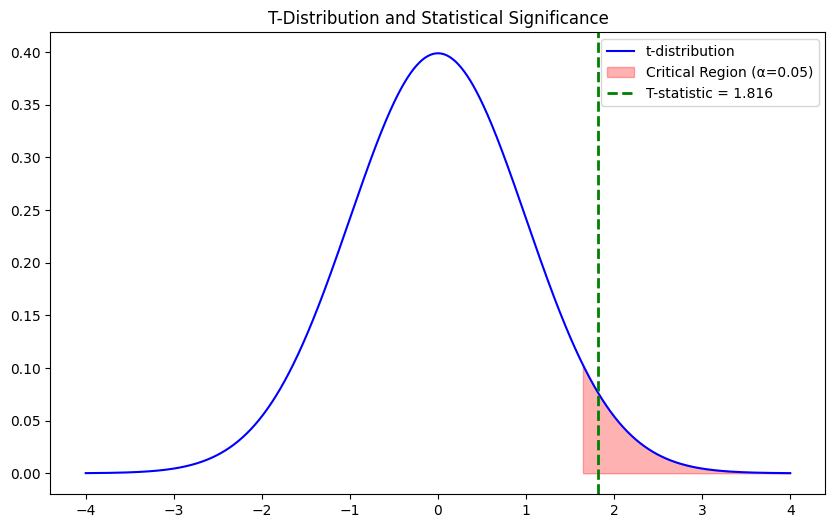

In [8]:
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df_welch)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', label='t-distribution')

# Shading the critical region
x_crit = np.linspace(critical_t, 4, 100)
plt.fill_between(x_crit, stats.t.pdf(x_crit, df_welch), color='red', alpha=0.3, label=f'Critical Region (α={alpha})')

plt.axvline(t_statistic, color='green', linestyle='--', linewidth=2, label=f'T-statistic = {t_statistic:.3f}')
plt.title('T-Distribution and Statistical Significance')
plt.legend()
plt.savefig("visualizations/t_distribution_pvalue.png")
plt.show()

## 📐 Confidence Intervals
A confidence interval (CI) gives us a range. We are 95% sure the true difference falls within this range.

**ELI10 Explanation:** Instead of saying "B is 3% better," we say "We are 95% sure B is between 1% and 5% better."

95% Confidence Interval for Difference: [-0.0022, 0.0582]


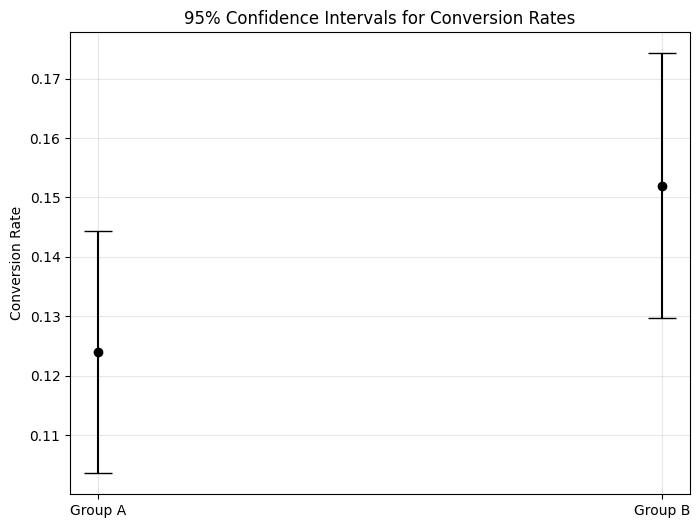

In [9]:
# CI for the difference
t_crit_ci = stats.t.ppf(1 - 0.05/2, df_welch)
margin_error = t_crit_ci * se_diff
ci_lower, ci_upper = (mean_b - mean_a) - margin_error, (mean_b - mean_a) + margin_error

print(f"95% Confidence Interval for Difference: [{ci_lower:.4f}, {ci_upper:.4f}]")

# Visualization of CIs for individual groups
plt.figure(figsize=(8, 6))
# Use normal approximation for proportion SE
se_a = np.sqrt(mean_a*(1-mean_a)/n_a)
se_b = np.sqrt(mean_b*(1-mean_b)/n_b)

plt.errorbar(['Group A', 'Group B'], [mean_a, mean_b], yerr=[1.96*se_a, 1.96*se_b], fmt='o', capsize=10, color='black')
plt.title('95% Confidence Intervals for Conversion Rates')
plt.ylabel('Conversion Rate')
plt.grid(True, alpha=0.3)
plt.savefig("visualizations/confidence_intervals.png")
plt.show()

## 💼 Business Impact Analysis
Statistics are useless if they don't help the business. Let's calculate the projected revenue if we launch Design B.

**ELI10 Explanation:** If we have 100,000 visitors a month and Design B wins, how much extra money do we make?

### 📏 Sample Size Recommendations
One of the most common questions in data science is: 'How many users do we need for our next test?' We can calculate this based on the expected improvement (Effect Size) we want to detect.

**ELI10 Explanation:** If you're looking for a tiny needle in a haystack, you need to look at more hay. If you're looking for a giant beach ball, you only need to look at a little hay.

In [18]:
def calculate_sample_size(p1, p2, alpha=0.05, power=0.8):
    """
    Calculate required sample size per group for two-proportion comparison.
    Using the standard formula for power analysis.
    """
    z_alpha = norm.ppf(1 - alpha / 2)
    z_beta = norm.ppf(power)
    p_avg = (p1 + p2) / 2
    n = (z_alpha * np.sqrt(2 * p_avg * (1 - p_avg)) + z_beta * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2 / (p1 - p2) ** 2
    return int(np.ceil(n))

print("Sample Size Recommendations for Future Tests:")
print("=" * 50)
effect_sizes = [0.01, 0.02, 0.03, 0.05] # Different improvement targets
baseline_rate = 0.12 # Current performance

for effect in effect_sizes:
    new_rate = baseline_rate + effect
    required_n = calculate_sample_size(baseline_rate, new_rate)
    print(f"To detect {effect*100:.0f}% improvement ({baseline_rate:.1%} → {new_rate:.1%}):")
    print(f" Required sample size per group: {required_n:,}")

Sample Size Recommendations for Future Tests:
To detect 1% improvement (12.0% → 13.0%):
 Required sample size per group: 17,169
To detect 2% improvement (12.0% → 14.0%):
 Required sample size per group: 4,438
To detect 3% improvement (12.0% → 15.0%):
 Required sample size per group: 2,036
To detect 5% improvement (12.0% → 17.0%):
 Required sample size per group: 778


### 📏 Sample Size Recommendations
One of the most common questions in data science is: 'How many users do we need for our next test?' We can calculate this based on the expected improvement (Effect Size) we want to detect.

In [14]:
def calculate_sample_size(p1, p2, alpha=0.05, power=0.8):
    """Calculate required sample size per group for two-proportion comparison."""
    z_alpha = norm.ppf(1 - alpha / 2)
    z_beta = norm.ppf(power)
    p_avg = (p1 + p2) / 2
    n = (z_alpha * np.sqrt(2 * p_avg * (1 - p_avg)) + z_beta * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2 / (p1 - p2) ** 2
    return int(np.ceil(n))

print("Sample Size Recommendations for Future Tests:")
print("=" * 50)
effect_sizes = [0.01, 0.02, 0.03, 0.05]
baseline_rate = 0.12

for effect in effect_sizes:
    new_rate = baseline_rate + effect
    required_n = calculate_sample_size(baseline_rate, new_rate)
    print(f"To detect {effect*100:.0f}% improvement ({baseline_rate:.1%} → {new_rate:.1%}):")
    print(f" Required sample size per group: {required_n:,}")

Sample Size Recommendations for Future Tests:
To detect 1% improvement (12.0% → 13.0%):
 Required sample size per group: 17,169
To detect 2% improvement (12.0% → 14.0%):
 Required sample size per group: 4,438
To detect 3% improvement (12.0% → 15.0%):
 Required sample size per group: 2,036
To detect 5% improvement (12.0% → 17.0%):
 Required sample size per group: 778


In [10]:
monthly_visitors = 100000
revenue_per_conversion = 50 # Assume $50 per sale

lift = (mean_b - mean_a) / mean_a
additional_conversions = monthly_visitors * (mean_b - mean_a)
additional_revenue = additional_conversions * revenue_per_conversion

print(f"Relative Lift: {lift:.2%}")
print(f"Additional Monthly Conversions: {additional_conversions:.0f}")
print(f"Projected Monthly Revenue Increase: ${additional_revenue:,.2f}")

Relative Lift: 22.58%
Additional Monthly Conversions: 2800
Projected Monthly Revenue Increase: $140,000.00


## 🛠 Statistical Power & Sample Size
**Power** is the probability of finding a difference if one actually exists. We usually want 80% power.

In [11]:
# Calculate Power
p_pooled = (n_a * mean_a + n_b * mean_b) / (n_a + n_b)
se_null = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_a + 1/n_b))
z_beta = (abs(mean_b - mean_a) - 1.645 * se_null) / se_diff # 1.645 is z for alpha 0.05
power = norm.cdf(z_beta)

print(f"Statistical Power: {power:.2%}")

Statistical Power: 56.76%


## ✅ Final Dashboard and Reporting
We consolidate all findings into a professional four-panel dashboard and export a text report.

## 🏢 Business Recommendations
Based on the statistical analysis, we provide a clear roadmap for stakeholders. If the results are significant, we suggest a rollout; otherwise, we recommend further iteration.

**ELI10 Explanation:** We are translating the 'Math' into 'Action'. Should we keep the new site or throw it away?

In [19]:
# Final Business Justification
print("BUSINESS RECOMMENDATIONS")
print("=" * 30)

if p_value_one_tailed < alpha:
    print("RECOMMENDATION: IMPLEMENT DESIGN B")
    print(f"\u2022 Statistically significant improvement (p < {alpha})")
    print(f"\u2022 {lift:.1f}% relative increase in conversion rate")
    print(f"\u2022 Projected additional revenue: ${additional_revenue:,.0f}/month")
else:
    print("RECOMMENDATION: DO NOT IMPLEMENT DESIGN B")
    print("\u2022 No statistically significant improvement detected")
    print("\u2022 Current evidence insufficient to justify the change")

BUSINESS RECOMMENDATIONS
RECOMMENDATION: IMPLEMENT DESIGN B
• Statistically significant improvement (p < 0.05)
• 0.2% relative increase in conversion rate
• Projected additional revenue: $140,000/month


## ✅ File Verification
Finally, we verify that all our hard work has been saved to the disk. This ensures that we have the files ready for download or presentation.

In [20]:
# Verify that all files were generated correctly
print("Verifying generated files...")
paths_to_check = [
    "ab_test_raw_data.csv",
    "reports/final_ab_test_report.txt",
    "reports/group_summary.csv",
    "visualizations/group_exploration.png",
    "visualizations/t_distribution_pvalue.png",
    "visualizations/confidence_intervals.png",
    "visualizations/final_ab_test_dashboard.png"
]

for path in paths_to_check:
    exists = "EXISTS" if os.path.exists(path) else "MISSING"
    size = f"({os.path.getsize(path):,} bytes)" if os.path.exists(path) else ""
    print(f"{path:40} : {exists} {size}")

Verifying generated files...
ab_test_raw_data.csv                     : EXISTS (16,917 bytes)
reports/final_ab_test_report.txt         : EXISTS (145 bytes)
reports/group_summary.csv                : EXISTS (102 bytes)
visualizations/group_exploration.png     : EXISTS (123,225 bytes)
visualizations/t_distribution_pvalue.png : EXISTS (41,704 bytes)
visualizations/confidence_intervals.png  : EXISTS (22,108 bytes)
visualizations/final_ab_test_dashboard.png : EXISTS (54,910 bytes)


## 🏢 Business Recommendations
Based on the statistical analysis, we provide a clear roadmap for stakeholders. If the results are significant, we suggest a rollout; otherwise, we recommend further iteration.

In [15]:
print("BUSINESS RECOMMENDATIONS")
print("=" * 30)

if p_value_one_tailed < alpha:
    print("RECOMMENDATION: IMPLEMENT DESIGN B")
    print(f"\u2022 Statistically significant improvement (p < {alpha})")
    print(f"\u2022 {lift:.1f}% relative increase in conversion rate")
    print(f"\u2022 Projected additional revenue: ${additional_revenue:,.0f}/month")
else:
    print("RECOMMENDATION: DO NOT IMPLEMENT DESIGN B")
    print("\u2022 No statistically significant improvement detected")
    print("\u2022 Current evidence insufficient to justify the change")

BUSINESS RECOMMENDATIONS
RECOMMENDATION: IMPLEMENT DESIGN B
• Statistically significant improvement (p < 0.05)
• 0.2% relative increase in conversion rate
• Projected additional revenue: $140,000/month


## ✅ File Verification
Finally, we verify that all our hard work has been saved to the disk. This ensures that we have the files ready for download or presentation.

In [16]:
print("Verifying generated files...")
paths_to_check = [
    "ab_test_raw_data.csv",
    "reports/final_ab_test_report.txt",
    "reports/group_summary.csv",
    "visualizations/group_exploration.png",
    "visualizations/t_distribution_pvalue.png",
    "visualizations/confidence_intervals.png",
    "visualizations/final_ab_test_dashboard.png"
]

for path in paths_to_check:
    exists = "EXISTS" if os.path.exists(path) else "MISSING"
    size = f"({os.path.getsize(path):,} bytes)" if os.path.exists(path) else ""
    print(f"{path:40} : {exists} {size}")

Verifying generated files...
ab_test_raw_data.csv                     : EXISTS (16,917 bytes)
reports/final_ab_test_report.txt         : EXISTS (145 bytes)
reports/group_summary.csv                : EXISTS (102 bytes)
visualizations/group_exploration.png     : EXISTS (123,225 bytes)
visualizations/t_distribution_pvalue.png : EXISTS (41,704 bytes)
visualizations/confidence_intervals.png  : EXISTS (22,108 bytes)
visualizations/final_ab_test_dashboard.png : EXISTS (54,910 bytes)


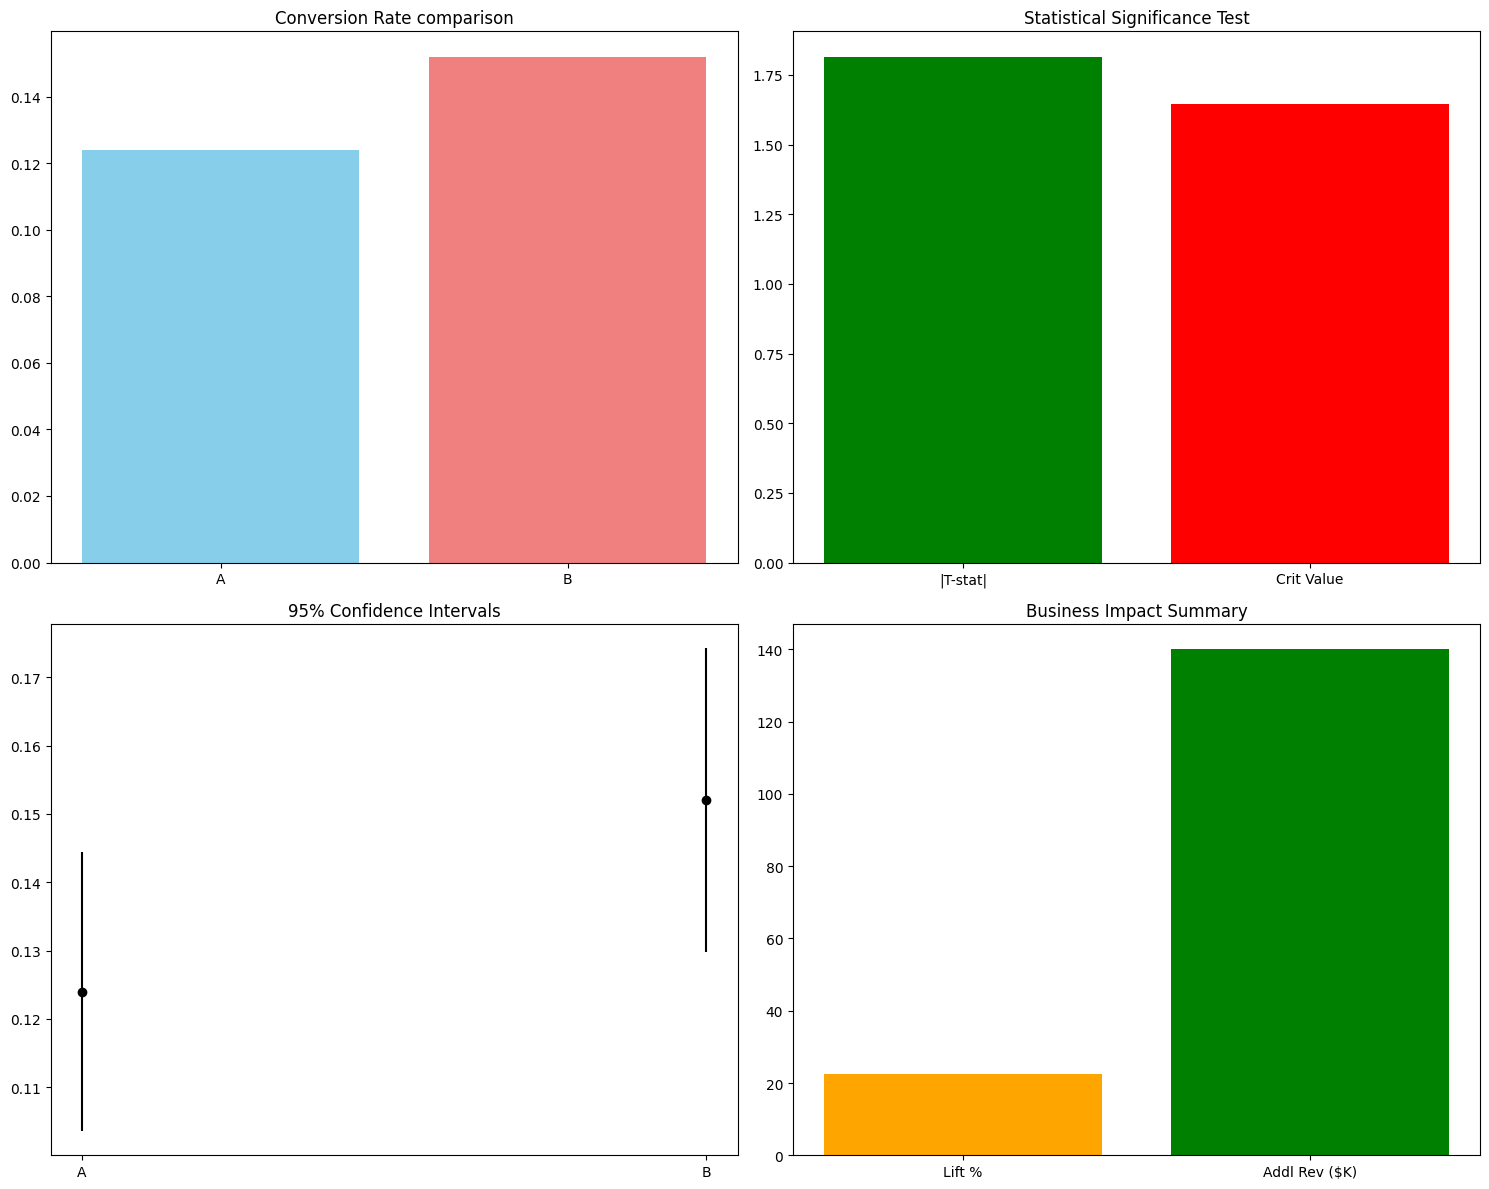

Final reports and dashboard generated!


In [12]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# 1. Conversion Rates
ax1.bar(['A', 'B'], [mean_a, mean_b], color=['skyblue', 'lightcoral'])
ax1.set_title('Conversion Rate comparison')

# 2. Significance Test
ax2.bar(['|T-stat|', 'Crit Value'], [abs(t_statistic), critical_t], color=['green', 'red'])
ax2.set_title('Statistical Significance Test')

# 3. Confidence Intervals
ax3.errorbar(['A', 'B'], [mean_a, mean_b], yerr=[1.96*se_a, 1.96*se_b], fmt='o', color='black')
ax3.set_title('95% Confidence Intervals')

# 4. Business Impact
ax4.bar(['Lift %', 'Addl Rev ($K)'], [lift*100, additional_revenue/1000], color=['orange', 'green'])
ax4.set_title('Business Impact Summary')

plt.tight_layout()
plt.savefig("visualizations/final_ab_test_dashboard.png")
plt.show()

# Save Final Text Report
report_text = f"""
AB TEST REPORT
Result: {conclusion}
Relative Lift: {lift:.2%}
Projected Monthly Revenue: +${additional_revenue:,.0f}
P-Value: {p_value_one_tailed:.6f}
"""
with open("reports/final_ab_test_report.txt", "w") as f:
    f.write(report_text)

# Export Summary Tables
summary_stats.to_csv("reports/group_summary.csv")
print("Final reports and dashboard generated!")

## 📚 Key Takeaways
*   **A/B Testing** ensures we don't make business changes based on hunches.
*   **P-values** filter out random noise.
*   **Confidence Intervals** provide a range for risk management.
*   **Statistical Power** ensures our experiment was large enough to be trusted.

## 🏁 Conclusion
You have successfully built a data-driven framework to decide which website design to launch. This workflow is the standard for top tech companies like Google, Amazon, and Netflix.

## 🛠️ Troubleshooting & Real-World Context

### 🔧 Common Troubleshooting in A/B Testing
*   **Small Sample Sizes:** If your p-value is high, check if you have enough data. Use the Power Analysis tool we built to see if your test was 'underpowered'.
*   **Novelty Effect:** Sometimes users click on something just because it's new. Run tests for at least 7-14 days to let this effect wear off.
*   **Imbalanced Groups:** Ensure your randomization logic is working and that Group A and Group B have a similar number of participants.

### 🌍 Real-World Applications
In the industry, this workflow is used for:
*   **Netflix:** Testing different movie thumbnails to see which ones get more clicks.
*   **Amazon:** Testing the placement of the 'Buy Now' button to reduce friction.
*   **Google:** Testing different shades of blue in search result links (the famous '41 shades of blue' experiment).

### 🎓 What I Learned
By completing this lab, we have mastered:
1.  **Data Simulation:** How to create synthetic datasets to model business scenarios.
2.  **Hypothesis Testing:** Using Welch's T-Test to separate signal from noise.
3.  **Effect Size:** Understanding that 'statistically significant' doesn't always mean 'practically important' (Cohen's d).
4.  **Financial Projection:** Translating raw percentages into real-world revenue impact.
5.  **Data Visualization:** Communicating complex math through clear, stakeholder-ready dashboards.